# Task 6: House Price Prediction

**Objective:** Build a machine learning model that predicts house prices based on features like area, number of bedrooms, bathrooms, and other property attributes. This is a regression problem; predicting a continuous number, not a category.

In [1]:
# Importing Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print('Libraries Imported Successfully')

Libraries Imported Successfully


In [2]:
# Load and inspect Data

df = pd.read_csv('Housing.csv')
print('Shape: ',df.shape)
print(df.head())

Shape:  (545, 13)
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [3]:
# Checking missing values

print('Missing values: ')
print(df.isnull().sum())

print('\nTypes:')
print(df.dtypes)

Missing values: 
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Types:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object


In [4]:
# Convert text columns into numbers

le =LabelEncoder()
text_columns =['mainroad','basement','guestroom', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

for cols in text_columns:
    df[cols] = le.fit_transform(df[cols])

print('Done. Sample after encoding:')
df.head()

Done. Sample after encoding:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


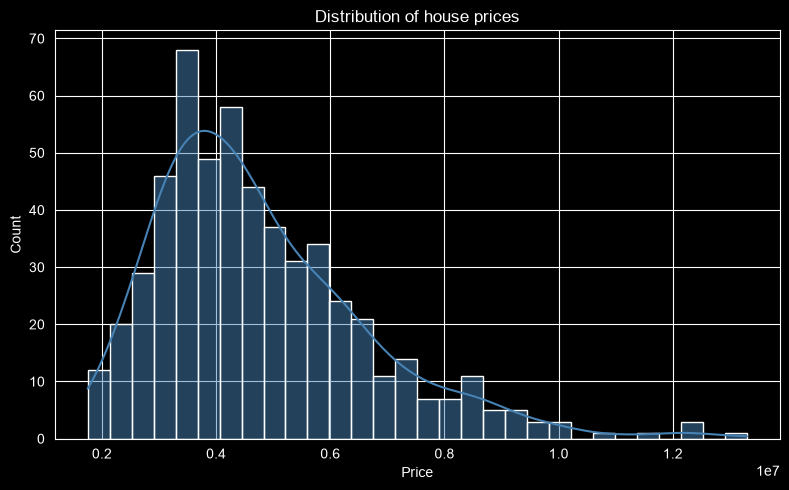

In [5]:
# Visulaization

plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of house prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
# Split and target

X = df.drop('price', axis=1)
y = df['price']

X_train , X_test , y_train , y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Training set: ' , X_train.shape)
print('Test set: ', X_test.shape)

Training set:  (436, 12)
Test set:  (109, 12)


In [7]:
# Model Training

model = LinearRegression()
model.fit(X_train, y_train)
print('Model trained successfully')

Model trained successfully


In [8]:
# Prediction and Evaluate

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:,.0f}')
print(f'MSE: {mse:,.0f}')
print(f'RMSE: {rmse:,.0f}')
print(f'R2 Score: {r2:,.4f}')

MAE: 979,680
MSE: 1,771,751,116,594
RMSE: 1,331,071
R2 Score: 0.6495


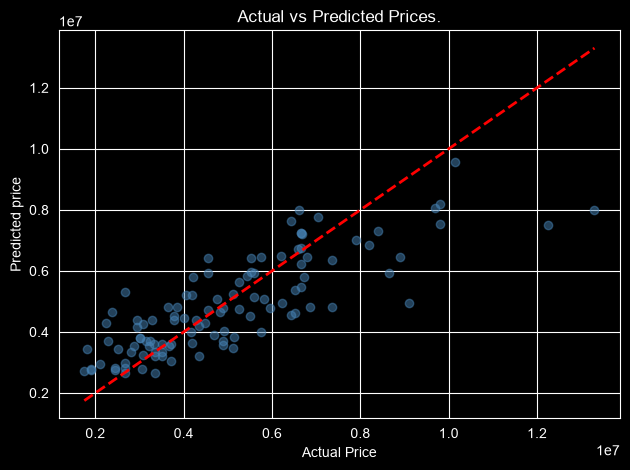

In [11]:
# Visualize actual vs predicted prices

plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted Prices.')
plt.xlabel('Actual Price')
plt.ylabel('Predicted price')
plt.tight_layout()
plt.show()

#Summary

1. Dataset includes 545 rows(houses) and 13 columns(features).
2. Data is mostly clean and has no null values but mainroad, basement, guestroom, hotwaterheating, airconditioning, prefarea and furnishingstatus values needed to be converted into numbers as they were texts.
3. Histogram shows that data is skewed and most house prices are mid ranged just like in real life housing market.
4. Model prediction is off by almost one million, which can be bad and good depending on price range. It also tells that 65% of the things that changes prices are included in data set, other 35% things that could affect price of property is not included in dataset.
5. Scatter plot shows that model is good for predicting low and mid ranged house prices, it struggles on luxury properties prediction because these properties includes things that are not present in the dataset.